<a href="https://colab.research.google.com/github/sweety-12/DeepFake-detection-project/blob/Trying-CNN-%2BCBAM-model-to-improve-accuracy/CNN_CBAM_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notes

**PyTorch Fundamentals:**

What are Tensors really? How they work behind the scenes (storage, strides, views)?

How Autograd (automatic differentiation) works internally.

**Neural Networks in PyTorch:**

Building custom models with nn.Module.

Forward, backward pass, and how optimization (optimizer.step()) is actually happening.

**Advanced Topics:**

Custom loss functions and layers.

Writing custom training loops (instead of using Trainer APIs like PyTorch Lightning etc.).

Mixed Precision Training (for faster training using less memory).

Deployment using TorchScript and ONNX.

Best Practices:

How to manage large codebases with PyTorch (e.g., project structure, data pipelines).

Debugging models, using hooks, visualizing gradients, etc.




**Pytorch:**

Think of it like this:

Analogy	Meaning

PyTorch	-> Like a "factory"

Tensors	-> Like the "raw material"

Models, CNNs -> Like "products" made from that material

Training	-> The "manufacturing process"



1. What is Tensor?

  -> A tensor is basically a multi-dimensional array.

  -> Its like a NumPy array but it can do 3 extra things:
       
       -> It can run on GPU(for speed)
       -> It can track gradients(for learning)
       -> It can be saved/loaded easily in Pytorch models

    Tensors are building blocks of everything in PyTorch.

#2. Creating Tensors

import torch

#create A 1D Tensor
a = torch.tensor([1, 2, 3])

#create a 2D tensor (Matrix)
b = torch.tensor([[1, 2], [3, 4]])
print(b)


#3. Tensor Basics

#Adding two numbers
x = torch.tensor([1, 2])
y = torch.tensor([3, 4])

print(x+y)  


#4. Tensor and GPU
->check if GPU is available

device = torch.device('cuda' if torch.cuda.is_available() else  'cpu')

print(device)


-> Move tensor to GPU

a = a.to(device)
print(a)

#5. Tensors and Gradient
What is Gradient?

Gradient = Slope = How much a function is changing at a point.

It's a rate of change

In deep learning, the model learns by adjusting weights to minimize the loss.


In Pytorch Terms:

When we create a tensor with requires_grad = True,

Pytorch tracks all operations done on it,
so later you can call .backward() an it will automatically compute the gradients.

example:

Create a tensor aand ask it to track gradients

x = torch.tensor(2.0, requires_grad = True)

Define a function based on x

y = x^2 + 3*x + 4

Compute the gradient(backward pass)

y.backward()

now x.grad contains the gradient of y with respect to x

print(x.grad)

📌 Why do we care about Gradients?

   Without gradients, models won't learn.






#What is Autograd?

In Pytorch, Autograd is the system that automatically calculates gradients for you.
Instead of manually applyling calculas

Pytorch builds a dynamic computation graph behind the scenes.

#💬 Everyday analogy:
Imagine you're baking a cake.

Every step (add flour, add sugar, mix) is recorded.

At the end, you want to figure out:

"If I added slightly more flour, how would it change the cake?"

Autograd remembers every step and tells you how the final cake would change if you tweaked anything.

#🏆 You have now understood:
Real model structure

Forward pass

Loss computation

Backward pass (Autograd)



#Next natural topics in PyTorch are:

#📚 Next Topics:
Step	Topic	Why important?

1	Common Layers (Linear, Conv2d, ReLU, etc.)	You need these to design any neural network

2	Loss Functions	-> To calculate "how wrong" model is

3	Optimizers	-> To update model weights based on gradients

4	Training Loop -> 	To train the model on real data

5	Dataset and Dataloader	-> To feed data into the model in batches



#Common Layers in PyTorch

1. nn.linear

Used for fully connected layers

2. nn.Conv2d

Used for image processing(CNN). Instead of matrix multiplication, it slides small filters over images.

3. Activation functions

After a layer, you usually apply activation to introduce non-linearity.



















# **Setting up Coding Environment**

In [1]:
#install necessary packages
!pip install -q torch torchvision torchaudio   #pytorch for buildidng and training models
!pip install -q matplotlib scikit-learn opencv-python   #for plotting and image handling
!pip install -q albumentations tqdm    #for data augmentation and progress bars



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 123.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.5 MB/s eta 0:00:00


**Import Libraries**

In [2]:
#pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset

#other libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from tqdm import tqdm

**Dataset Collection**

Get a dataset that contains both real and fake images for training your model

we will use the fake and reak faces dataset for easier and fater training at the start.

In [3]:
from google.colab import files
files.upload()  #upload the kaggle.json file here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sweetykumari12082001","key":"0de9bae6201f343ff38dd6ef734be170"}'}

Authenticate and Download Dataset

In [4]:
#save the key and download the dataset
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

#Download the fake and real dataset(small and good for starters)
!kaggle datasets download -d ciplab/real-and-fake-face-detection
!unzip -q real-and-fake-face-detection.zip -d data

Dataset URL: https://www.kaggle.com/datasets/ciplab/real-and-fake-face-detection
License(s): CC-BY-NC-SA-4.0
 96% 416M/431M [00:03<00:00, 121MB/s] 
100% 431M/431M [00:03<00:00, 139MB/s]


**Data Preprocessing and DataLoader Creation**

This step will prepare the image so your model can understand and learn from them

In [7]:
from PIL import Image
#These help standardize and augment the input data

from torchvision import transforms

transform_train = transforms.Compose([
    #transforms.Lambda(lambda image: image.convert('RGB')),  #Convert all images to RGB
    transforms.Resize((128, 128)),   #Resize all images to 128x128
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),            #Convert to PyTorch tensor(0-1 range)
    transforms.Normalize(mean = [0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  #Normalize to [-1, 1]
])

transform_val = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

**Load Dataset using ImageFolder**

Imagefolder automatically labels folders real - 0, fake - 1.

In [8]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

# 1. Load full dataset *without* transform for now
full_dataset = ImageFolder("data/real_and_fake_face")

# 2. Split into training and validation datasets
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# 3. Manually assign different transforms to each subset
train_dataset.dataset.transform = transform_train
val_dataset.dataset.transform = transform_val

# 4. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 5. Check classes
print("Classes:", full_dataset.classes)  # ['fake', 'real']


Classes: ['training_fake', 'training_real']


Visualize Sample Images

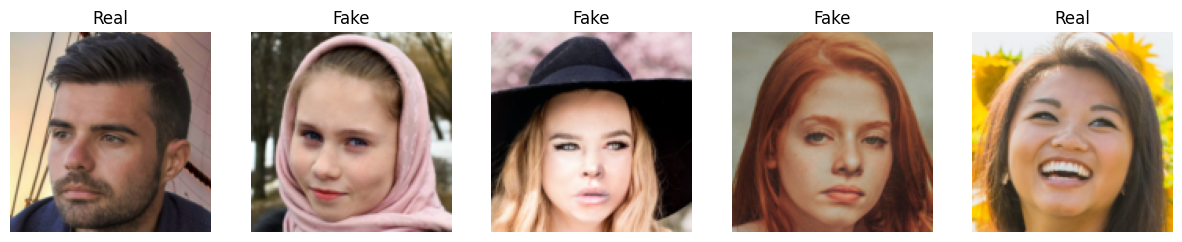

In [9]:
def show_batch(loader):
  images, labels = next(iter(loader))
  fig, ax = plt.subplots(1, 5, figsize=(15, 3))
  for i in range(5):
    img = images[i].permute(1,2, 0)* 0.5 + 0.5  #undo normalization
    label = "Real" if labels[i] == 1 else "Fake"
    ax[i].imshow(img)
    ax[i].set_title(label)
    ax[i].axis('off')


show_batch(train_loader)


# Build the Deep Fake Detection Model

Create a Convolutional Neural Network(CNN) that learns to classify images as real(1) or fake (0)

**Define a Simple CNN Architecture**

we'll keep it simple to start with and later i can experiment with advanced models and ResNet, Efficient, or Xception

In [31]:
# # class DeepFakeCNN(nn.Module):
# #   def __init__(self):
# #     super(DeepFakeCNN, self).__init__()
# #     self.conv1 = nn.Conv2d(3, 16, kernel_size =3, padding=1)
# #     self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
# #     self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
# #     self.pool = nn.MaxPool2d(2, 2)
# #     self.dropout = nn.Dropout(0.3)
# #     self.fc1 = nn.Linear(64 * 16 * 16, 128)
# #     self.fc2 = nn.Linear(128, 1)


# #   def forward(self, x):
# #     x = self.pool(F.relu(self.conv1(x)))
# #     x = self.pool(F.relu(self.conv2(x)))
# #     x = self.pool(F.relu(self.conv3(x)))
# #     x = x.view(-1, 64 * 16 * 16)
# #     x = self.dropout(F.relu(self.fc1(x)))
# #     x = torch.sigmoid(self.fc2(x))
# #     return x


# # IMPROVING THE MODEL FOR ACCURACY
# # class DeepFakeHybridModel(nn.Module):
# #     def __init__(self):
# #         super(DeepFakeHybridModel, self).__init__()

# #         self.cnn = nn.Sequential(
# #             nn.Conv2d(3, 32, kernel_size=3, padding=1),  # (B, 3, 128, 128) -> (B, 32, 128, 128)
# #             nn.BatchNorm2d(32),
# #             nn.ReLU(),
# #             nn.MaxPool2d(2),  # -> (B, 32, 64, 64)

# #             nn.Conv2d(32, 64, kernel_size=3, padding=1),
# #             nn.BatchNorm2d(64),
# #             nn.ReLU(),
# #             nn.MaxPool2d(2),  # -> (B, 64, 32, 32)

# #             nn.Conv2d(64, 128, kernel_size=3, padding=1),
# #             nn.BatchNorm2d(128),
# #             nn.ReLU(),
# #             nn.MaxPool2d(2),  # -> (B, 128, 16, 16)

# #             nn.Conv2d(128, 256, kernel_size=3, padding=1),
# #             nn.BatchNorm2d(256),
# #             nn.ReLU(),
# #             nn.AdaptiveAvgPool2d((4, 4))  # -> (B, 256, 4, 4)
# #         )

# #         self.fc = nn.Sequential(
# #             nn.Flatten(),  # (B, 256*4*4)
# #             nn.Linear(256*4*4, 256),
# #             nn.ReLU(),
# #             nn.Dropout(0.4),
# #             nn.Linear(256, 64),
# #             nn.ReLU(),
# #             nn.Dropout(0.4),
# #             nn.Linear(64, 1),
# #             nn.Sigmoid()
# #         )

# #     def forward(self, x):
# #         x = self.cnn(x)
# #         x = self.fc(x)
# #         x = self.pool(F.relu(self.bn3(self.conv3(x))))
# #         x = self.pool(F.relu(self.bn4(self.conv4(x))))
# #         return x


# #####################################
# class DeepFakeCNNImproved(nn.Module):
#     def __init__(self):
#         super(DeepFakeCNNImproved, self).__init__()
#         self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
#         self.bn1 = nn.BatchNorm2d(32)

#         self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
#         self.bn2 = nn.BatchNorm2d(64)

#         self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
#         self.bn3 = nn.BatchNorm2d(128)

#         self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
#         self.bn4 = nn.BatchNorm2d(256)

#         self.pool = nn.MaxPool2d(2, 2)
#         self.dropout = nn.Dropout(0.4)

#         self.fc1 = nn.Linear(256 * 8 * 8, 256)
#         self.fc2 = nn.Linear(256, 1)

#     def forward(self, x):
#         x = self.pool(F.relu(self.bn1(self.conv1(x))))
#         x = self.pool(F.relu(self.bn2(self.conv2(x))))
#         x = self.pool(F.relu(self.bn3(self.conv3(x))))
#         x = self.pool(F.relu(self.bn4(self.conv4(x))))

#         x = x.view(-1, 256 * 8 * 8)
#         x = self.dropout(F.relu(self.fc1(x)))
#         x = torch.sigmoid(self.fc2(x))
#         return x


In [10]:
# Channel Attention Module
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // reduction, in_planes, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)

# Spatial Attention Module
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(x))

In [11]:
class ResidualCBAMBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualCBAMBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.ca = ChannelAttention(out_channels)
        self.sa = SpatialAttention()

        self.downsample = None
        if in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out = self.ca(out) * out
        out = self.sa(out) * out

        if self.downsample is not None:
            identity = self.downsample(identity)

        out += identity
        return self.relu(out)

In [12]:
class DeepFakeCBAMCNN(nn.Module):
    def __init__(self):
        super(DeepFakeCBAMCNN, self).__init__()
        self.layer1 = ResidualCBAMBlock(3, 32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.layer2 = ResidualCBAMBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.layer3 = ResidualCBAMBlock(64, 128)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, 1)

    def forward(self, x):
        x = self.pool1(self.layer1(x))
        x = self.pool2(self.layer2(x))
        x = self.pool3(self.layer3(x))

        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = torch.sigmoid(self.fc2(x))
        return x

**Initialize Model, Loss and Optimizer**

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepFakeCBAMCNN().to(device)

#Binary classification = use BCE Loss
criterion = nn.BCELoss()

#Adam optimizer(you can experiment later)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

**Training Function**

Here we'll loop over epochs, update weights and print training loss.

In [15]:
def train(model, loader, optimizer, criterion):
  model.train()
  running_loss = 0.0
  for images, labels in tqdm(loader):
    images, labels = images.to(device), labels.float().to(device)
    labels = labels.view(-1, 1)  #Reshape for BCE loss

    #Forward + Backward + Optimize
    outputs = model(images)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
  return running_loss / len(loader)

**Validation Function**

to evaluate how well the model performs on unseen data

In [16]:
def evaluate(model, loader, criterion):
  model.eval()
  total_loss = 0.0
  correct = 0
  total = 0
  with torch.no_grad():
    for images, labels in loader:
      images, labels = images.to(device), labels.float().to(device)
      labels = labels.view(-1,1)
      outputs = model(images)
      loss = criterion(outputs, labels)
      total_loss += loss.item()

      predicted = (outputs > 0.5).float()
      correct += (predicted == labels).sum().item()
      total += labels.size(0)
    return total_loss / len(loader), correct / total

In [17]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


**Train the Model**

In [18]:
early_stopping = EarlyStopping(patience=5)

num_epochs = 30
for epoch in range(num_epochs):
  train_loss = train(model, train_loader, optimizer, criterion)
  val_loss, val_acc = evaluate(model, val_loader, criterion)
  if early_stopping(val_loss):
        print("Early stopping triggered.")
        break
  print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

100%|██████████| 51/51 [00:21<00:00,  2.38it/s]


Epoch 1/30 - Train Loss: 45.5398, Val Loss: 50.6635, Val Acc: 0.4963


100%|██████████| 51/51 [00:20<00:00,  2.48it/s]


Epoch 2/30 - Train Loss: 46.2010, Val Loss: 50.6635, Val Acc: 0.4963


100%|██████████| 51/51 [00:19<00:00,  2.55it/s]


...

Epoch 28/30 - Train Loss: 46.2010, Val Loss: 50.6635, Val Acc: 0.4963


100%|██████████| 51/51 [00:20<00:00,  2.49it/s]


Epoch 29/30 - Train Loss: 46.2010, Val Loss: 50.6635, Val Acc: 0.4963


100%|██████████| 51/51 [00:20<00:00,  2.50it/s]


Epoch 30/30 - Train Loss: 46.2010, Val Loss: 50.6635, Val Acc: 0.4963


**Evaluate and Testing the Deepfake detector**

Goal
Evaluate model performance on validation data
visualize predictions
Generate metrics like accuracy, confusion matrix, precision, and recall

Predict and visualize on sample images

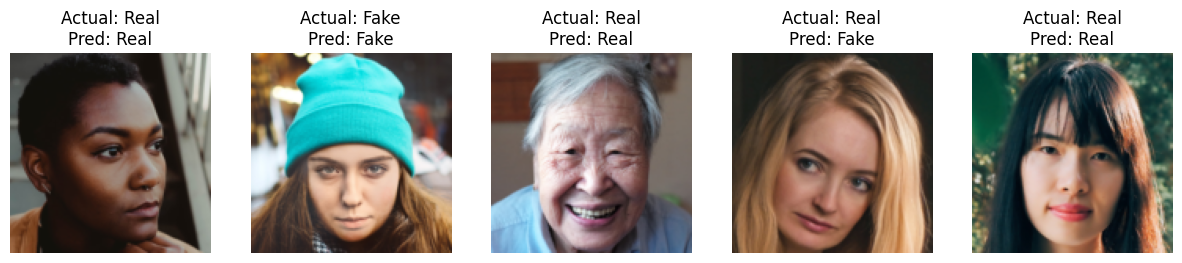

In [13]:
def predict_and_show(model, loader):
  model.eval()
  images, labels = next(iter(loader))
  images, labels = images.to(device), labels.to(device)

  outputs = model(images)
  preds = (outputs > 0.5).int()

  fig, ax = plt.subplots(1, 5, figsize = (15, 3))
  for i in range(5):
    img = images[i].cpu().permute(1, 2, 0) * 0.5 + 0.5
    actual = "Real" if labels[i] == 1 else "Fake"
    predicted = "Real" if preds[i] == 1 else "Fake"
    ax[i].imshow(img)
    ax[i].set_title(f"Actual: {actual}\nPred: {predicted}")
    ax[i].axis('off')

predict_and_show(model, val_loader)

**Evaluation Metrics**

Let's compute accuracy, precision, recall and confusion matrix

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def evaluate_metrics(model, loader):
  model.eval()
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for images, labels in loader:
      images = images.to(device)
      labels = labels.to(device)
      outputs = model(images)
      preds = (outputs > 0.5).int().cpu().numpy()
      all_preds.extend(preds)
      all_labels.extend(labels.cpu().numpy())

    #convert to numpy
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    #Metrics
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print("Confusion Matrix:\n", cm)

evaluate_metrics(model, val_loader)


Accuracy: 0.5892
Precision: 0.6111
Recall: 0.5288
Confusion Matrix:
 [[131  70]
 [ 98 110]]


**Test on Your Own image(Real or Fake)**

In [18]:
#this cell is used tp upload an image
from google.colab import files
uploaded = files.upload()

Saving fake1.jpg to fake1.jpg


In [19]:
from PIL import Image

def predict_image(image_path, model):
  model.eval()
  img = Image.open(image_path).convert('RGB')
  img = transform(img)  #use the same transform as training
  img = img.unsqueeze(0).to(device)  #Add batch dimension

  with torch.no_grad():
    output = model(img)
    prediction = (output > 0.5).int().item()


  label = "Real" if prediction == 1 else "Fake"
  print(f"Prediction: {label}")

  #show image
  plt.imshow(Image.open(image_path))
  plt.title(f"Prediction: {label}")
  plt.axis('off')
  plt.show()


Prediction: Real


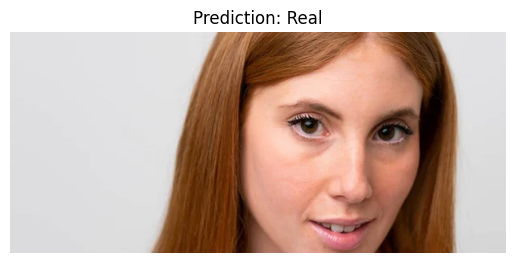

In [21]:
predict_image("fake1.jpg", model)